# Overview
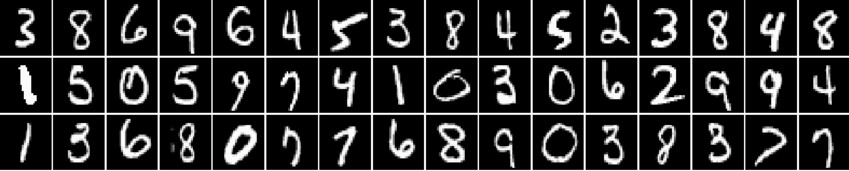

Hello, in this notebook we will use PyTorch to create a Feed Forward neural network in order to recognize/classify digits from the MNIST data set.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load the data
Take a quick look at the data, plot it (really nice) split it to features (our X) and labels (our y) nad then in train and test sets.

In [3]:
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# just prin the head of the data frame
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We can observe that we have 785 columns, the first column being the label (our target, what we are trying to find, 0 - 9 digit value). 
We should split the data in our features and labels/target sets, our X and y.
Please note the our features set has the expected number of features/columns, 784 which is 28 * 28 as our pictures are 28 by 28.

In [4]:
X = df.drop(["label"], axis = 1)
y = df["label"]

print(f"the shape of X is {X.shape} and the shape of y is {y.shape}")

the shape of X is (42000, 784) and the shape of y is (42000,)


Now let's do a plotting of the data, to see what we actually have and it looks very cool :)

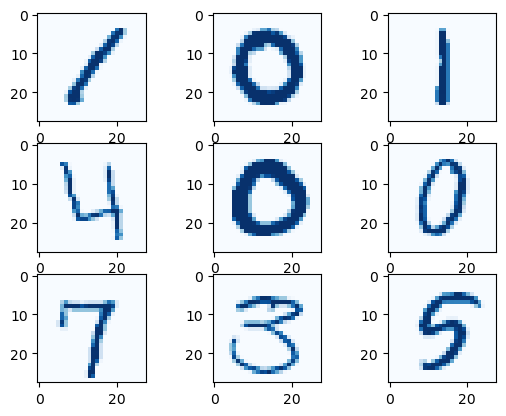

In [5]:
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X.iloc[i].values.reshape(28, 28), cmap="Blues")

plt.show()

Indeed we can see we are working with images of digits, each digit being 0 - 9 and the image is 28 * 28 pixels. 

Now let's take the opportunity to split the train data into train and test, we will use sklearn's train_test_split. We will use 20% of the data for the test data set.

In [6]:
XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.2)

print(f"shape of XTrain: {XTrain.shape}, shape of yTrain: {yTrain.shape}, shape of XTest: {XTest.shape}, shape of yTest: {yTest.shape}")

shape of XTrain: (33600, 784), shape of yTrain: (33600,), shape of XTest: (8400, 784), shape of yTest: (8400,)


# Transofrm the data to tensors
Let's transform the data frames to PyTorch tensors.

In [7]:
XTrain = torch.tensor(XTrain.values)
yTrain = torch.tensor(yTrain.values)

XTest = torch.tensor(XTest.values)
yTest = torch.tensor(yTest.values)

Let's do a plot of the data similar to what we did before just to check if we loaded the data correctly (also it's still cool:D)

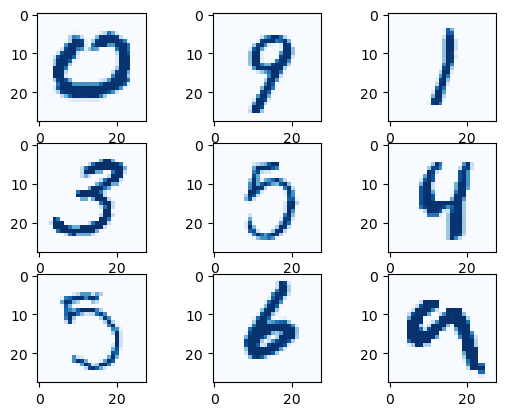

In [8]:
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(XTrain[i].reshape(28, 28), cmap="Blues")
    
plt.show()

# Create the class representing our neural network

In [9]:
class FeedForwardNN(nn.Module):
    def __init__(self, inputSize, hiddenSize, numberOfClasses):
        super(FeedForwardNN, self).__init__()

        self.linear1 = nn.Linear(inputSize, hiddenSize)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hiddenSize, numberOfClasses)

    def forward(self, x):
        out = self.linear1(x)
        out = self.relu(out)
        out = self.linear2(out)

        return out

Let's instantiate the class representing our neural network, but first we should declare some hyper parameters.

In [10]:
# hyper parameters
inputSize = 784 # our images are 28x28
hiddenSize = 100
numberOfClasses = 10 # the number of classes/labels, the digits from 0 to 9
numberOfEpochs = 2
batchSize = 100
learningRate = 0.001

In [11]:
model = FeedForwardNN(inputSize, hiddenSize, numberOfClasses)

Now we need and an loss function and optimizer. Please note that we use the CrossEntropy Loss function from torch, and this applies softmax for us so we should not apply it manually.

In [12]:
lossFunction = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)

# Training loop
We need a training loop to traing our method.

In [13]:
for epoch in range(numberOfEpochs):
    i = 0
    size = len(XTrain)
    while i * batchSize < size:
        localX = XTrain[i * batchSize: (i + 1) * batchSize]
        localLabels = yTrain[i * batchSize: (i + 1) * batchSize]

        # we need to reshape the images, now they are 100, 1, 28, 28
        # and out imput size is 784, asa ca tensorul nostru trebuie sa fie 100, 784

        images = localX.reshape(-1, 28 * 28).to(torch.float32)

        # forward
        outputs = model(images)
        loss = lossFunction(outputs, localLabels)
        # back prop

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"epoch is {epoch}, i is {i}, localX size {len(localX)} out of {size}, loss is {loss:.4f}")

        i += 1

epoch is 0, i is 0, localX size 100 out of 33600, loss is 31.3068
epoch is 0, i is 100, localX size 100 out of 33600, loss is 0.4979
epoch is 0, i is 200, localX size 100 out of 33600, loss is 0.4145
epoch is 0, i is 300, localX size 100 out of 33600, loss is 0.2108
epoch is 1, i is 0, localX size 100 out of 33600, loss is 0.1470
epoch is 1, i is 100, localX size 100 out of 33600, loss is 0.2580
epoch is 1, i is 200, localX size 100 out of 33600, loss is 0.3086
epoch is 1, i is 300, localX size 100 out of 33600, loss is 0.1145


Please note the loos is getting smaller.

# Test accuracy of the model
We will now test the accuracy of trained model.

In [14]:
# keep track of the predictions and actual values/labels to be used latter in the confusion matrix
predictions = np.empty((0, XTest.shape[0]), np.int32)
actualValues = np.empty((0, XTest.shape[0]), np.int32)

with torch.no_grad():
    numberOfCorrectPredictions = 0
    numberOFSamples = 0

    i = 0
    size = len(XTest)

    while i * batchSize < size:

        localX = XTest[i * batchSize: (i + 1) * batchSize]
        localLabels = yTest[i * batchSize: (i + 1) * batchSize]

        images = localX.reshape(-1, 28 * 28).to(torch.float32)
        outputs = model(images)

        # max returns the value and the class/index/labels
        _, prediction = torch.max(outputs, 1)
        numberOFSamples += localLabels.shape[0]
        numberOfCorrectPredictions += (prediction == localLabels).sum().item()

        predictions = np.append(predictions, prediction.detach().numpy())
        actualValues = np.append(actualValues, localLabels.detach().numpy())
        
        if i % 20 == 0:
            print(f"test iteration {i}")
        i += 1


print(f"accuracy: {(100.0 * (numberOfCorrectPredictions/ numberOFSamples)):.4f}")

test iteration 0
test iteration 20
test iteration 40
test iteration 60
test iteration 80
accuracy: 93.7857


As you can see we get the accuracy of 94.7024, which is pretty decent.

# Confusion matrix
Now let's print a confusion matrix. A confusion matrix tells us how ofthen our model was correct or wrong, for each label.

<AxesSubplot:>

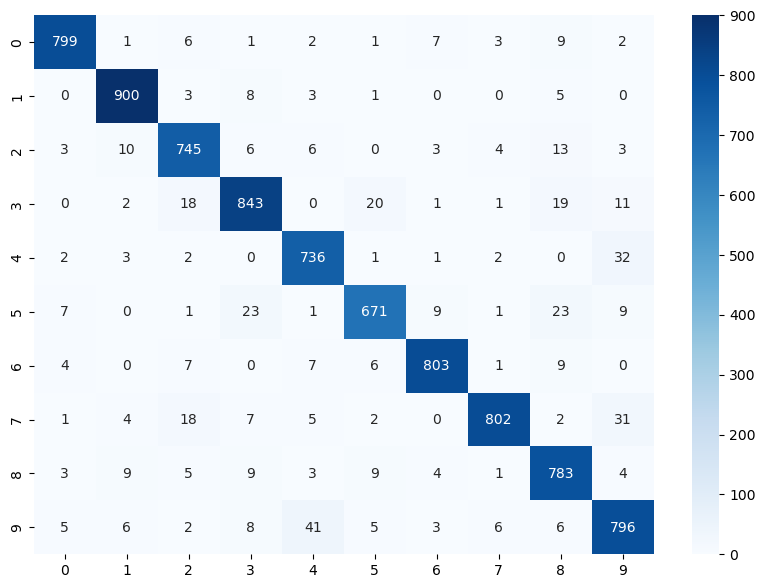

In [15]:
confusionMatrix = confusion_matrix(actualValues, predictions)

confusionMatrixDf = pd.DataFrame(confusionMatrix, index = [i for i in "0123456789"], columns = [i for i in "0123456789"])
plt.figure(figsize = (10,7))
sns.heatmap(confusionMatrixDf, annot=True, cmap='Blues', fmt='g')

# Do the actual prediction and output the results file
We will create submission.csv file with our results, please note this will submit the results from your account if you run this. 

In [16]:
dfTest = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

test = torch.tensor(dfTest.values)

file = open('submission.csv','w')

file.write("ImageId,Label\n")

size = len(test)
for i in range(size):
    image = test[i].reshape(-1, 28 * 28).to(torch.float32)
    outputs = model(image)
    _, prediction = torch.max(outputs, 1)

    file.write(f"{i + 1},{prediction.item()}\n")


file.close()

# Finish!
And we made it to the finish, hope you like this!